# 📡 Telco Customer Churn — Exploratory & ML Analysis
## Jupyter Notebook companion to `app_improved.py`

This notebook covers the full data science workflow:
1. Data Loading & Inspection
2. Exploratory Data Analysis (EDA)
3. Pre-processing Pipeline
4. Feature Engineering
5. Model Training & Evaluation (7 classifiers)
6. Cross-Validation
7. Feature Importance
8. Live Prediction Demo

> **Note:** The Streamlit app (`app_improved.py`) wraps this exact pipeline in an interactive UI.
> This notebook lets you explore and modify each step interactively.


## 1. Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)

# Plot style
plt.style.use("dark_background")
plt.rcParams.update({"figure.facecolor": "#0d1628", "axes.facecolor": "#141f38",
                     "axes.edgecolor": "#1e2d4a", "grid.color": "#1a2840",
                     "text.color": "#c8d6f0", "axes.labelcolor": "#c8d6f0",
                     "xtick.color": "#6a84b0", "ytick.color": "#6a84b0",
                     "figure.dpi": 120})

COLORS  = ["#4f8ef7","#7b5cf4","#34c77b","#f5a623","#ef4b6c","#00c9b1","#f06292"]
GOOD, DANGER, WARN = "#34c77b", "#ef4b6c", "#f5a623"
print("✅ Imports done")


✅ Imports done


## 2. Data Loading

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Prefer the real CSV bundled with this project when it exists.
# Otherwise create synthetic data so the notebook still runs end-to-end.
# ─────────────────────────────────────────────────────────────────────────────
from pathlib import Path

data_path = Path.cwd() / "Telco_Customer_Churn.csv"
if data_path.exists():
    df_raw = pd.read_csv(data_path)
    print(f"Loaded real file: {data_path}")
else:
    df_raw = generate_sample_telco(n=500, seed=42)
    print("No CSV found in the project folder; using synthetic sample data.")

print(f"Shape      : {df_raw.shape}")
print(f"Churn rate : {(df_raw['Churn']=='Yes').mean()*100:.1f}%")
df_raw.head()


Loaded real file: d:\DS\CapstoneProject1\Telco_Customer_Churn.csv
Shape      : (7043, 21)
Churn rate : 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis

In [5]:
# ── 3a. Basic info ────────────────────────────────────────────────────────────
print("\n--- Column dtypes ---")
print(df_raw.dtypes)
print("\n--- Missing values ---")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print("\n--- Class balance ---")
print(df_raw["Churn"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")



--- Column dtypes ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

--- Missing values ---
Series([], dtype: int64)

--- Class balance ---
Churn
No     73.5%
Yes    26.5%
Name: proportion, dtype: object


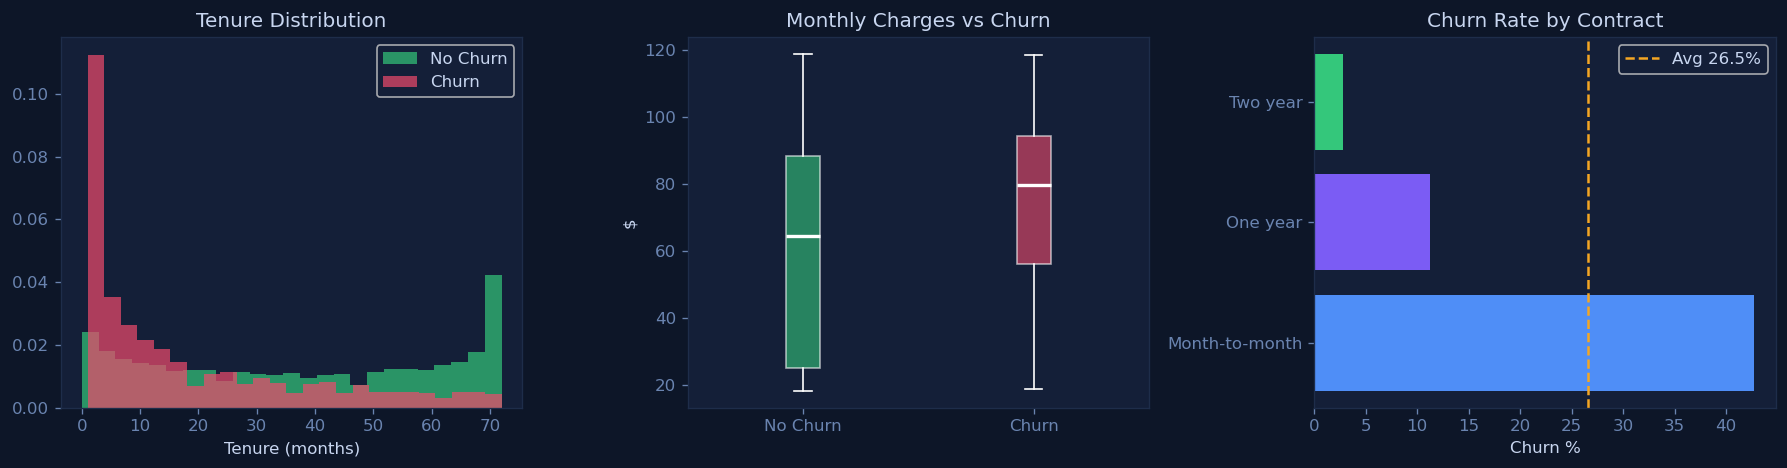

In [6]:
# ── 3b. Tenure distribution by churn ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_raw[df_raw["Churn"]=="No"]["tenure"],  bins=25, alpha=0.7,
             color=GOOD,   label="No Churn", density=True)
axes[0].hist(df_raw[df_raw["Churn"]=="Yes"]["tenure"], bins=25, alpha=0.7,
             color=DANGER, label="Churn",    density=True)
axes[0].set_title("Tenure Distribution")
axes[0].set_xlabel("Tenure (months)")
axes[0].legend()

# Monthly charges boxplot
for label, color in [("No", GOOD), ("Yes", DANGER)]:
    sub = df_raw[df_raw["Churn"]==label]["MonthlyCharges"]
    axes[1].boxplot(sub, positions=[0 if label=="No" else 1],
                    patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color="white", linewidth=2))
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(["No Churn","Churn"])
axes[1].set_title("Monthly Charges vs Churn"); axes[1].set_ylabel("$")

# Churn rate by contract type
ct = df_raw.groupby("Contract")["Churn"].apply(lambda x:(x=="Yes").mean()*100)
axes[2].barh(ct.index, ct.values, color=COLORS[:len(ct)])
axes[2].axvline(df_raw["Churn"].eq("Yes").mean()*100, color=WARN,
                linestyle="--", label=f"Avg {df_raw['Churn'].eq('Yes').mean()*100:.1f}%")
axes[2].set_title("Churn Rate by Contract"); axes[2].set_xlabel("Churn %")
axes[2].legend()

plt.tight_layout(); plt.show()


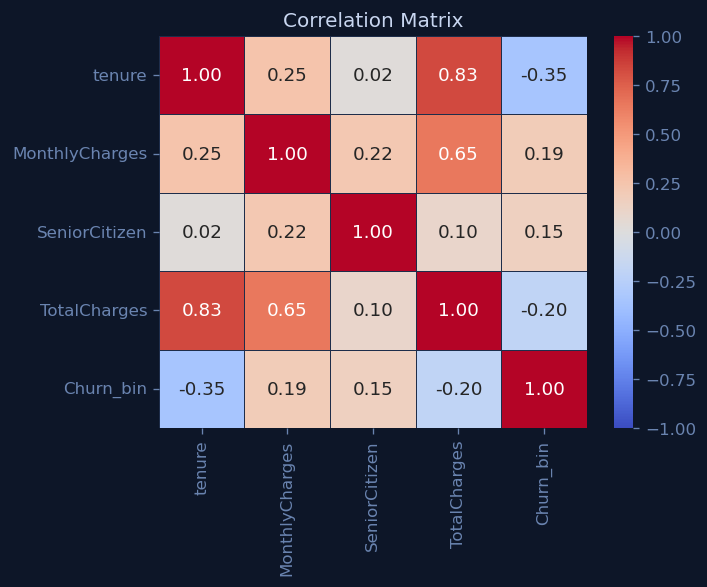

In [7]:
# ── 3c. Correlation heatmap (numeric + Churn) ─────────────────────────────────
num = df_raw[["tenure","MonthlyCharges","SeniorCitizen"]].copy()
num["TotalCharges"] = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")
num["Churn_bin"] = (df_raw["Churn"]=="Yes").astype(int)
corr = num.corr().round(2)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0,
            linewidths=0.5, linecolor="#1e2d4a", ax=ax,
            annot_kws={"size":11}, fmt=".2f", vmin=-1, vmax=1)
ax.set_title("Correlation Matrix")
plt.tight_layout(); plt.show()


## 4. Pre-processing Pipeline

In [8]:
df = df_raw.copy()
df.drop(columns=["customerID"], inplace=True, errors="ignore")

# Step 1 — Fix TotalCharges (spaces / blanks → numeric → fill median)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
print(f"Missing after fix: {df['TotalCharges'].isnull().sum()}")

# Step 2 — Binary map (Yes/No and gender)
binary_map = {"Yes":1,"No":0,"Male":1,"Female":0,
              "No phone service":0,"No internet service":0}
binary_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling",
               "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
               "StreamingTV","StreamingMovies"]
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map(binary_map).fillna(0).astype(int)

# Step 3 — One-hot encode multi-category columns
ohe_cols = ["MultipleLines","InternetService","Contract","PaymentMethod"]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
df[df.select_dtypes("bool").columns] = df.select_dtypes("bool").astype(int)

# Target encode
df["Churn"] = (df["Churn"]=="Yes").astype(int)

print(f"Columns after OHE: {df.shape[1]}")
df.head(3)


Missing after fix: 0
Columns after OHE: 25


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,1,0,1,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,1,0,0,...,1,0,0,0,0,0,0,0,0,1


## 5. Feature Engineering

In [9]:
# ── AvgMonthlySpend ──────────────────────────────────────────────────────────
df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)
# Why: normalises spend by how long the customer has been with the company.

# ── TenureGroup ───────────────────────────────────────────────────────────────
df["TenureGroup"] = pd.cut(df["tenure"], bins=[0,12,24,48,72],
                            labels=[0,1,2,3], include_lowest=True
                           ).astype(float).fillna(0).astype(int)
# Why: tenure–churn relationship is non-linear; binning captures 4 lifecycle stages.

# ── ServiceCount ──────────────────────────────────────────────────────────────
svc_cols = ["OnlineSecurity","OnlineBackup","DeviceProtection",
            "TechSupport","StreamingTV","StreamingMovies"]
existing_svc = [c for c in svc_cols if c in df.columns]
df["ServiceCount"] = df[existing_svc].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)
# Why: more services = higher switching cost → lower churn probability.

df = df.fillna(0)

print("Engineered features added: AvgMonthlySpend, TenureGroup, ServiceCount")
print(f"Final feature count: {df.shape[1] - 1}")


Engineered features added: AvgMonthlySpend, TenureGroup, ServiceCount
Final feature count: 27


## 6. Train / Test Split & Scaling

In [10]:
X = df.drop(columns=["Churn"]).astype(np.float64)
y = df["Churn"]
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y preserves the churn ratio in both sets

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_sc  = scaler.transform(X_test)        # transform test with train's params

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")


Train: (5634, 27) | Test: (1409, 27)
Train churn rate: 26.5% | Test: 26.5%


## 7. Model Training — 7 Classifiers

In [11]:
models_def = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42), True),
    "Decision Tree":       (DecisionTreeClassifier(class_weight="balanced", max_depth=8, random_state=42), False),
    "Random Forest":       (RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=42), False),
    "Gradient Boosting":   (GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, random_state=42), False),
    "SVM":                 (SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42), True),
    "KNN":                 (KNeighborsClassifier(n_neighbors=7), True),
    "Naive Bayes":         (GaussianNB(), False),
}
# class_weight="balanced" → model auto-upweights minority (Churn=Yes) class
# use_scaled=True         → distance-based models (LR, SVM, KNN) need StandardScaler

results, roc_data = {}, {}

for name, (model, use_scaled) in models_def.items():
    Xtr = X_train_sc if use_scaled else X_train.values
    Xte = X_test_sc  if use_scaled else X_test.values
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:,1]

    results[name] = {
        "model":     model,
        "scaled":    use_scaled,
        "accuracy":  round(accuracy_score(y_test,  y_pred), 4),
        "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "recall":    round(recall_score(y_test,    y_pred, zero_division=0), 4),
        "f1":        round(f1_score(y_test,        y_pred, zero_division=0), 4),
        "auc":       round(roc_auc_score(y_test,   y_prob), 4),
        "cm":        confusion_matrix(y_test, y_pred),
    }
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr)
    print(f"{name:22s}  AUC={results[name]['auc']:.3f}  Recall={results[name]['recall']:.3f}")


Logistic Regression     AUC=0.846  Recall=0.781
Decision Tree           AUC=0.802  Recall=0.751
Random Forest           AUC=0.825  Recall=0.481
Gradient Boosting       AUC=0.844  Recall=0.505
SVM                     AUC=0.821  Recall=0.770
KNN                     AUC=0.793  Recall=0.513
Naive Bayes             AUC=0.823  Recall=0.778


## 8. Evaluation

In [12]:
# ── Metrics table ─────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    "Model":     list(results.keys()),
    "Accuracy":  [r["accuracy"]  for r in results.values()],
    "Precision": [r["precision"] for r in results.values()],
    "Recall":    [r["recall"]    for r in results.values()],
    "F1":        [r["f1"]        for r in results.values()],
    "AUC-ROC":   [r["auc"]       for r in results.values()],
}).sort_values("AUC-ROC", ascending=False).reset_index(drop=True)
metrics_df


,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Logistic Regression,0.7424,0.5096,0.7807,0.6167,0.8464
1,Gradient Boosting,0.7977,0.6540,0.5053,0.5701,0.8441
2,Random Forest,0.7864,0.6272,0.4813,0.5446,0.8245
3,Naive Bayes,0.7374,0.5035,0.7781,0.6113,0.8233
4,SVM,0.7445,0.5125,0.7701,0.6154,0.8214
5,Decision Tree,0.7353,0.5009,0.7513,0.6011,0.8016
6,KNN,0.7651,0.5630,0.5134,0.5371,0.7926


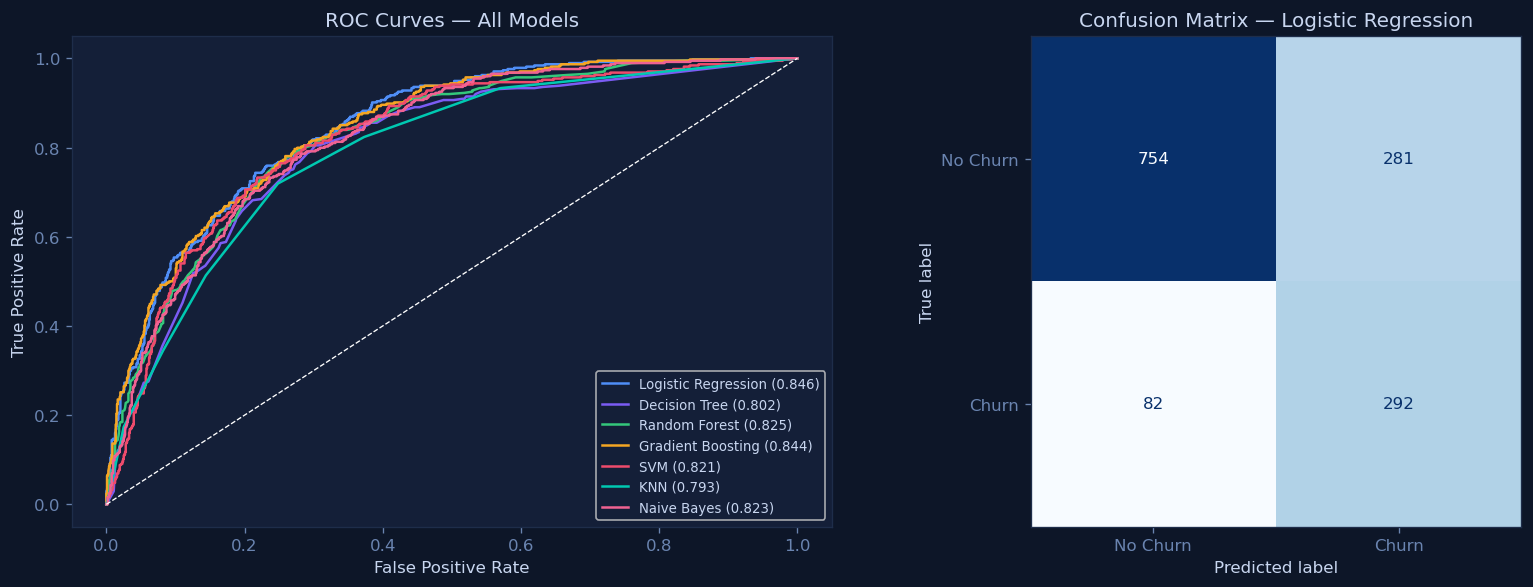

Best model by Recall: Logistic Regression


In [13]:
# ── ROC curves ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, (fpr, tpr)) in enumerate(roc_data.items()):
    axes[0].plot(fpr, tpr, color=COLORS[i % 7], linewidth=1.5,
                 label=f"{name} ({results[name]['auc']:.3f})")
axes[0].plot([0,1],[0,1], "w--", linewidth=0.8)
axes[0].set_title("ROC Curves — All Models")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)

# ── Best model confusion matrix ───────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]["recall"])
cm = results[best_name]["cm"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No Churn","Churn"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"Confusion Matrix — {best_name}")

plt.tight_layout(); plt.show()
print(f"Best model by Recall: {best_name}")


## 9. Cross-Validation (Top 3 Models)

Random Forest           CV AUC = 0.826 ± 0.010
Gradient Boosting       CV AUC = 0.847 ± 0.011
Logistic Regression     CV AUC = 0.849 ± 0.012


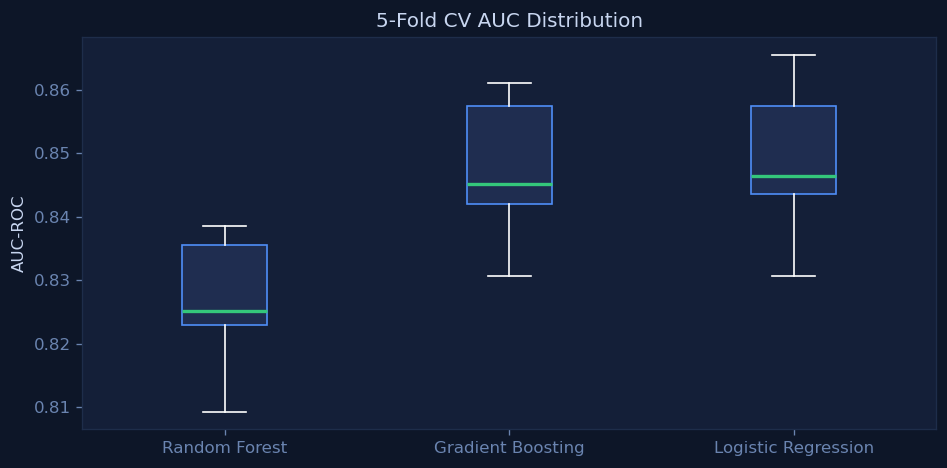

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}
top3 = ["Random Forest", "Gradient Boosting", "Logistic Regression"]

for name in top3:
    r = results[name]
    Xtr = X_train_sc if r["scaled"] else X_train.values
    scores = cross_val_score(r["model"], Xtr, y_train,
                             cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_scores[name] = scores
    print(f"{name:22s}  CV AUC = {scores.mean():.3f} ± {scores.std():.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([cv_scores[n] for n in top3], labels=top3,
           patch_artist=True,
           boxprops=dict(facecolor="#1f2d50", color="#4f8ef7"),
           medianprops=dict(color=GOOD, linewidth=2))
ax.set_title("5-Fold CV AUC Distribution")
ax.set_ylabel("AUC-ROC")
plt.tight_layout(); plt.show()


## 10. Feature Importance (Random Forest)

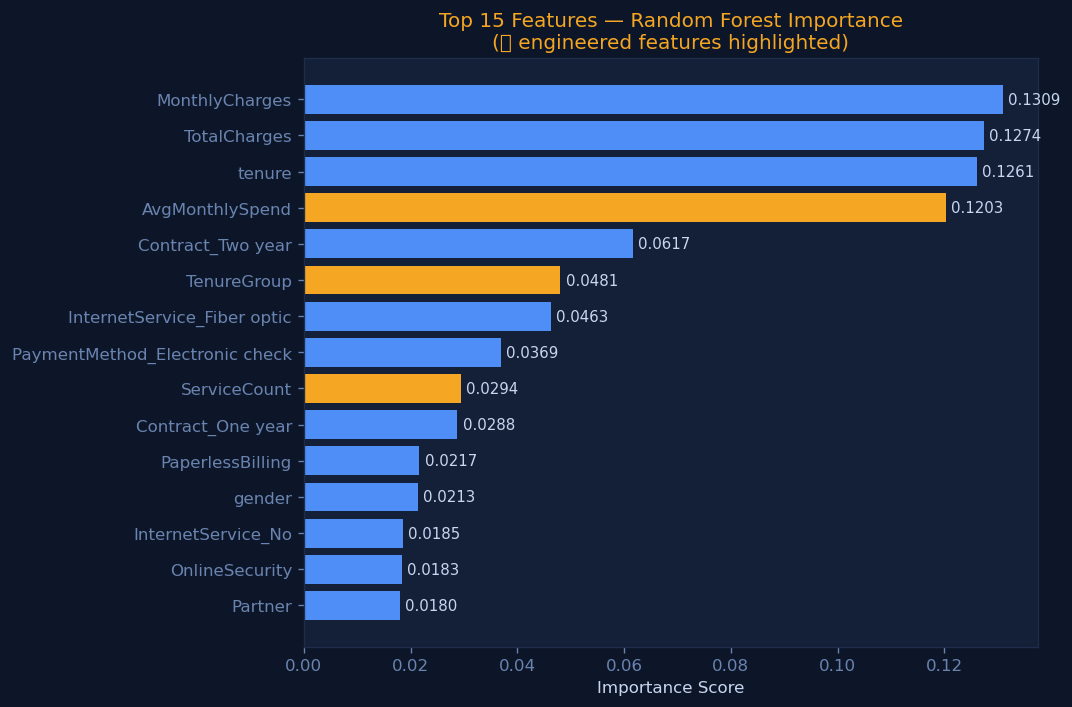

In [15]:
rf_model = results["Random Forest"]["model"]
fi = pd.Series(rf_model.feature_importances_,
               index=feature_names).sort_values(ascending=False)

eng_feats = {"AvgMonthlySpend", "TenureGroup", "ServiceCount"}
colors_fi  = [WARN if n in eng_feats else COLORS[0] for n in fi.head(15).index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(fi.head(15).index[::-1],
               fi.head(15).values[::-1],
               color=colors_fi[::-1])
ax.set_title("Top 15 Features — Random Forest Importance\n"
             "(🟡 engineered features highlighted)", color=WARN)
ax.set_xlabel("Importance Score")
for bar, val in zip(bars, fi.head(15).values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9, color="#c8d6f0")
plt.tight_layout(); plt.show()


## 11. Live Single-Customer Prediction Demo

In [16]:
# ── Build a customer profile dict ─────────────────────────────────────────────
customer = {n: 0 for n in feature_names}

# Demographics
customer["gender"]          = 1       # Male
customer["SeniorCitizen"]   = 0
customer["Partner"]         = 0
customer["Dependents"]      = 0
customer["tenure"]          = 3       # Only 3 months with company

# Services
customer["PhoneService"]    = 1
customer["OnlineSecurity"]  = 0
customer["OnlineBackup"]    = 0
customer["DeviceProtection"]= 0
customer["TechSupport"]     = 0
customer["StreamingTV"]     = 1
customer["StreamingMovies"] = 1

# Billing
customer["MonthlyCharges"]  = 95.0
customer["TotalCharges"]    = 95.0 * 3
customer["PaperlessBilling"]= 1

# OHE columns
customer["InternetService_Fiber optic"] = 1   # high-churn segment
customer["Contract_Month-to-month"]     = 0   # already baseline from drop_first

# Engineered features
customer["AvgMonthlySpend"] = customer["TotalCharges"] / (customer["tenure"] + 1)
customer["TenureGroup"]     = 0  # 0-12 months
customer["ServiceCount"]    = sum([customer["OnlineSecurity"], customer["OnlineBackup"],
                                   customer["DeviceProtection"], customer["TechSupport"],
                                   customer["StreamingTV"], customer["StreamingMovies"]])

# ── Predict ───────────────────────────────────────────────────────────────────
rf = results["Random Forest"]["model"]
row = pd.DataFrame([customer]).reindex(columns=feature_names, fill_value=0).astype(np.float64)
prob = rf.predict_proba(row)[0][1]
pred = "Churn ⚠️" if prob >= 0.5 else "Stay ✅"

print(f"Churn Probability : {prob*100:.1f}%")
print(f"Prediction        : {pred}")
print(f"Risk Segment      : {'High 🔴' if prob>=0.6 else 'Medium 🟡' if prob>=0.35 else 'Low 🟢'}")


Churn Probability : 64.7%
Prediction        : Churn ⚠️
Risk Segment      : High 🔴


## 12. Summary & Next Steps

In [17]:
summary = pd.DataFrame({
    "Model":       list(results.keys()),
    "AUC-ROC":     [r["auc"]       for r in results.values()],
    "Recall":      [r["recall"]    for r in results.values()],
    "Precision":   [r["precision"] for r in results.values()],
    "F1":          [r["f1"]        for r in results.values()],
}).sort_values("AUC-ROC", ascending=False)

print("=== Final Leaderboard ===")
print(summary.to_string(index=False))
print()
best = summary.iloc[0]
print(f"🏆 Best model : {best['Model']}")
print(f"   AUC-ROC   : {best['AUC-ROC']:.3f}")
print(f"   Recall    : {best['Recall']*100:.1f}% — catches {best['Recall']*100:.0f}% of churners")
print()
print("Next steps you can try in this notebook:")
print("  • GridSearchCV to tune Random Forest hyperparameters")
print("  • SHAP values for individual prediction explanations")
print("  • Threshold tuning (ROC curve) to optimise recall vs precision")
print("  • Clustering (KMeans) to segment customers by behaviour")


=== Final Leaderboard ===
              Model  AUC-ROC  Recall  Precision     F1
Logistic Regression   0.8464  0.7807     0.5096 0.6167
  Gradient Boosting   0.8441  0.5053     0.6540 0.5701
      Random Forest   0.8245  0.4813     0.6272 0.5446
        Naive Bayes   0.8233  0.7781     0.5035 0.6113
                SVM   0.8214  0.7701     0.5125 0.6154
      Decision Tree   0.8016  0.7513     0.5009 0.6011
                KNN   0.7926  0.5134     0.5630 0.5371

🏆 Best model : Logistic Regression
   AUC-ROC   : 0.846
   Recall    : 78.1% — catches 78% of churners

Next steps you can try in this notebook:
  • GridSearchCV to tune Random Forest hyperparameters
  • SHAP values for individual prediction explanations
  • Threshold tuning (ROC curve) to optimise recall vs precision
  • Clustering (KMeans) to segment customers by behaviour
